In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations, product
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import os

from tqdm import tqdm
# from sdv.metadata import SingleTableMetadata
from numpy.core import multiarray
from sklearn.metrics import r2_score
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator

import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.cluster import KMeans

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing


device = torch.device('cpu')

# plt.style.use('ggplot')
plt.style.use('default')

import matplotlib as mpl
#set params for the article
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.labelsize'] = 18

#set params for the notebook
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 10
# mpl.rcParams['axes.labelsize'] = 14


# import category_encoders as ce

In [2]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from deap import base, creator, tools, algorithms
import random

In [10]:
def train(X: pd.DataFrame, y: pd.Series, model):
    mape_arr = []
    r2_arr = []
    
    for _ in range(5):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
        
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)
        
        mape_arr.append(mean_absolute_percentage_error(y_test.values, prediction))
        r2_arr.append(r2_score(y_test.values, prediction))
        
    
    return {'mape_mean': round(np.mean(mape_arr), 3), 'mape_std': round(np.std(mape_arr), 4),\
            'r2_mean': round(np.mean(r2_arr), 3), 'r2_std': round(np.std(r2_arr), 4)}

In [3]:
# np.random.seed(55551)

# def create_synth_dataset(n_samples, noise_std=0.1):
#     X = np.random.rand(n_samples, 2)
    
#     main_coef = np.array([2.0, 3.0])
#     special_coef = np.array([2.0, -8.0])
    
#     special_region1 = (X[:, 0] > 0.1) & (X[:, 0] < 0.3) & (X[:, 1] > 0.6) & (X[:, 1] < 0.8)
#     special_region2 = (X[:, 0] > 0.6) & (X[:, 0] < 0.8) & (X[:, 1] > 0.3) & (X[:, 1] < 0.5)
#     special_regions = special_region1 | special_region2
    
#     y = X.dot(main_coef) + 7 + np.random.randn(n_samples) * noise_std
#     y[special_regions] = X[special_regions].dot(special_coef) + X[special_regions][:, 0]**2 - 4 + np.random.randn(sum(special_regions)) * noise_std

#     X = pd.DataFrame(X)
#     y = pd.DataFrame(y)

#     return X, y


np.random.seed(55551)

def create_synth_dataset(n_samples, noise_std=0.1):
    X = np.random.rand(n_samples, 2)
    
    main_coef = np.array([2.0, 3.0])
    special_coef = np.array([2.0, -8.0])
    
    special_region1 = (X[:, 0] > 0.1) & (X[:, 0] < 0.3) & (X[:, 1] > 0.5) & (X[:, 1] < 0.8)
    special_region2 = (X[:, 0] > 0.5) & (X[:, 0] < 0.8) & (X[:, 1] > 0.3) & (X[:, 1] < 0.5)
    special_regions = special_region1 | special_region2
    
    y = X.dot(main_coef) + 7 + np.random.randn(n_samples) * noise_std
    y[special_regions] = X[special_regions].dot(special_coef) + X[special_regions][:, 0]**2 - 4 + np.random.randn(sum(special_regions)) * noise_std

    X = pd.DataFrame(X)
    y = pd.DataFrame(y)

    return X, y


# np.random.seed(55551)

# def create_synth_dataset(n_samples, noise_std=0.1):
#     X = np.random.rand(n_samples, 2)
    
#     main_coef = np.array([2.0, 3.0])
#     special_coef = np.array([2.0, -8.0])
    
#     special_region1 = (X[:, 0] > 0.1) & (X[:, 0] < 0.3) & (X[:, 1] > 0.2) & (X[:, 1] < 0.9)
#     special_region2 = (X[:, 0] > 0.3) & (X[:, 0] < 0.8) & (X[:, 1] > 0.3) & (X[:, 1] < 0.5)
#     special_regions = special_region1 | special_region2
    
#     y = X.dot(main_coef) + 7 + np.random.randn(n_samples) * noise_std
#     y[special_regions] = X[special_regions].dot(special_coef) + X[special_regions][:, 0]**2 - 4 + np.random.randn(sum(special_regions)) * noise_std

#     X = pd.DataFrame(X)
#     y = pd.DataFrame(y)

#     return X, y

In [4]:
X_ex, y_ex = create_synth_dataset(1000)

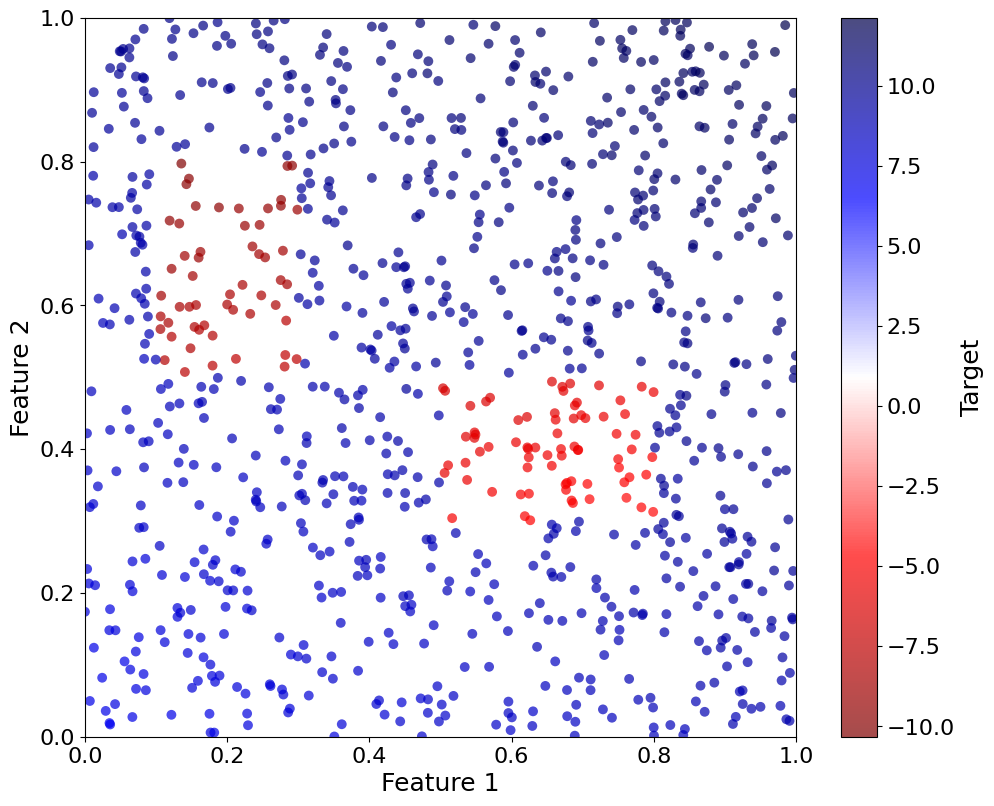

In [5]:
plt.figure(figsize=(10, 8))

sc = plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], c=y_ex, cmap='seismic_r', alpha=0.7, edgecolors='none', s=50)
plt.colorbar(sc, label='Target')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout(pad=0.5)
# plt.savefig('images/synthetic_dataset.pdf', dpi=300)
plt.show()

In [379]:
# np.random.seed(55555)

# X_ex1 = np.concatenate([np.random.uniform(0.0, 0.199, (100)), np.random.uniform(0.301, 0.599, (360)), np.random.uniform(0.701, 1.0, (340))]).reshape(-1, 1)
# np.random.shuffle(X_ex1)

# X_ex2 = np.concatenate([np.random.uniform(0.0, 0.999, (360)), np.random.uniform(0.301, 0.799, (340)), np.random.uniform(0.901, 1.0, (100))]).reshape(-1, 1)
# np.random.shuffle(X_ex2)


# X_ex = np.concatenate([X_ex1, X_ex2], axis=1)

# X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.2, 0.3, (30, 1)), np.random.uniform(0.0, 0.799, (30, 1))], axis=1)])
# X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.2, 0.3, (30, 1)), np.random.uniform(0.901, 1.0, (30, 1))], axis=1)])
# X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.6, 0.7, (30, 1)), np.random.uniform(0.0, 0.999, (30, 1))], axis=1)])
# X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.6, 0.7, (30, 1)), np.random.uniform(0.301, 1.0, (30, 1))], axis=1)])

# y_ex = 2 * X_ex[:, 0] + 3 * X_ex[:, 1] + 4 + np.random.normal(0, 0.1, (1000 - 80))
# # y_ex[np.random.randint(0, 1000, 10)] = y_ex[np.random.randint(0, 1000, 10)] + np.random.normal(0, 1, (10))
# # y_ex[np.where((X_ex[:, 0] < 0.2) & (X_ex[:, 0] > 0.1))[0]] = y_ex[np.where((X_ex[:, 0] < 0.2) & (X_ex[:, 0] > 0.1))[0]] + np.random.normal(0, 2)


# X_ex_b = np.concatenate([np.random.uniform(0.2, 0.3, (30, 1)), np.random.uniform(0.8, 0.9, (30, 1))], axis=1)
# y_ex_b = 2 * X_ex_b[:, 0] + 8 * X_ex_b[:, 1] - 32
# X_ex = np.concatenate([X_ex_b, X_ex])
# y_ex = np.concatenate([y_ex_b, y_ex])

# X_ex_b = np.concatenate([np.random.uniform(0.6, 0.7, (50, 1)), np.random.uniform(0.1, 0.3, (50, 1))], axis=1)
# y_ex_b = 2 * X_ex_b[:, 0] - 3 * X_ex_b[:, 1] + 1
# X_ex = np.concatenate([X_ex_b, X_ex])
# y_ex = np.concatenate([y_ex_b, y_ex])


# X_ex = pd.DataFrame(X_ex)
# y_ex = pd.DataFrame(y_ex)

In [380]:
# plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1])
# plt.show()

In [6]:
length_dict = {'length_cat_ordinal': 0, 'length_cat_onehot': [], 'length_num': 2}

## Baseline

In [8]:
def split_and_transform(X: pd.DataFrame, y: pd.DataFrame):
    scalers = {'scaler_X': MinMaxScaler(), 'scaler_y': MinMaxScaler(), 'ord_encoder': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)}
    
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    X_train, X_test, y_train, y_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True), y_train.reset_index(drop=True), y_test.reset_index(drop=True)
    
    X_train = pd.DataFrame(scalers['scaler_X'].fit_transform(X_train))
    X_test = pd.DataFrame(scalers['scaler_X'].transform(X_test))
    y_train = pd.DataFrame(scalers['scaler_y'].fit_transform(y_train.values.reshape(-1, 1)))
    y_test = pd.DataFrame(scalers['scaler_y'].transform(y_test.values.reshape(-1, 1)))
        
        
    return X_train, X_test, y_train, y_test, scalers


def train_model(model_type, X_train, y_train):
    model = model_type
    model.fit(X_train, y_train)
    
    return model


def evaluate_model(model_type, X, y):
    metrics = {'mse': [], 'r2': [], 'mape': []}
    
    for _ in range(31):
        X_train, X_test, y_train, y_test, scalers = split_and_transform(X, y)
        model = train_model(model_type, X_train, y_train)
        
        prediction = model.predict(X_test)
    
        metrics['mse'].append(mean_squared_error(y_test.values, prediction))
        metrics['r2'].append(r2_score(y_test.values, prediction))
        metrics['mape'].append(mean_absolute_percentage_error(y_test.values, prediction))
    
    metrics_df = pd.DataFrame([[np.mean(metrics['mse']), np.std(metrics['mse'])],
                               [np.mean(metrics['r2']), np.std(metrics['r2'])],
                               [np.mean(metrics['mape']), np.std(metrics['mape'])]], columns=['MEAN', 'STD'], index=['mse', 'r2', 'mape'])
        
    return metrics_df.round(3)

In [9]:
X_train, X_test, y_train, y_test, scalers = split_and_transform(X_ex, y_ex)

In [10]:
baseline_model = train_model(LinearRegression(), X_train, y_train)
new_model = train_model(XGBRegressor(), X_train, y_train)

In [11]:
baseline_prediction = baseline_model.predict(X_test).flatten()

In [12]:
evaluate_model(XGBRegressor(), X_ex, y_ex)

,MEAN,STD
mse,0.004,0.004
r2,0.942,0.055
mape,0.130,0.134


In [388]:
# scaler_X_train = MinMaxScaler()
# scaler_y_train = MinMaxScaler()
# data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

# X_train, X_test, y_train, y_test = train_test_split(data.drop('pricemetr', axis=1), data['pricemetr'], test_size=0.2, random_state=55555)
# X_train, X_test, y_train, y_test = train_test_split(X_ex, y_ex, test_size=0.2, random_state=55555)

# X_train = pd.DataFrame(scaler_X_train.fit_transform(X_train))
# X_test = pd.DataFrame(scaler_X_train.transform(X_test))
# y_train = pd.DataFrame(scaler_y_train.fit_transform(y_train.values.reshape(-1, 1)))
# y_test = pd.DataFrame(scaler_y_train.transform(y_test.values.reshape(-1, 1)))


# xgb = XGBRegressor()
# xgb = LinearRegression()

# xgb.fit(X_train, y_train)

In [389]:
# new_reg_model = XGBRegressor()
# new_reg_model.fit(X_train, y_train)

In [390]:
# xgb_pred = xgb.predict(X_test)

In [391]:
# plt.scatter(y_test.values, xgb_pred)
# plt.plot(np.linspace(0, 0.6, 10), np.linspace(0, 0.6, 10), color='black')
# plt.show()

## Select bad examples

In [13]:
def select_bad_examples(X: pd.DataFrame, y: pd.DataFrame, predictions: np.array, thrs: float = 0.05):
    idx_bad = np.where(np.abs(y.values.flatten() - predictions.flatten()) >= thrs)[0]
    bad_y = y.iloc[idx_bad]
    bad_X = X.iloc[idx_bad]
    
    return bad_X, bad_y

In [14]:
bad_X, bad_y = select_bad_examples(X_test, y_test, baseline_prediction, 0.1)

In [15]:
len(bad_X) / len(X_test)

0.535

In [16]:
bad_X

,0,1
0,0.070608,0.854102
1,0.290204,0.113049
3,0.364342,0.954234
4,0.315403,0.055911
5,0.441697,0.673567
...,...,...
191,0.770497,0.398956
193,0.035539,0.015606
194,0.329549,0.626957
196,0.401303,0.411701


In [17]:
# idx_bad = np.where(np.abs(y_test.values - xgb_pred) > 0.05)[0]
# bad_y = y_test.iloc[idx_bad]
# bad_X = X_test.loc[y_test.iloc[idx_bad].index]

In [18]:
bad_X.shape

(107, 2)

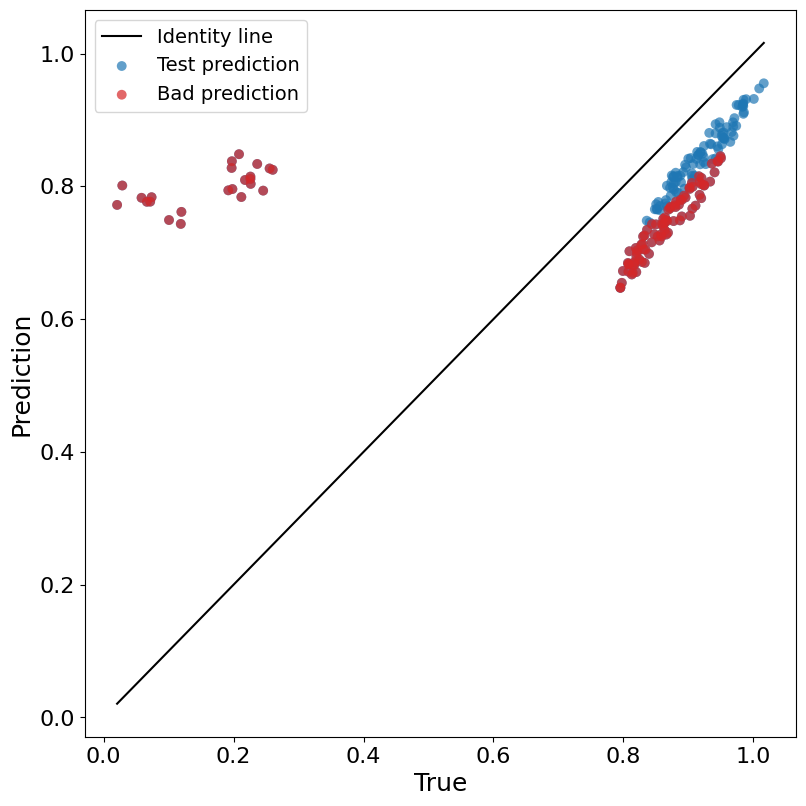

In [19]:
plt.figure(figsize=(8, 8))

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
plt.scatter(y_test.values, baseline_prediction, color='tab:blue', alpha=0.7, label='Test prediction', zorder=3, edgecolors='none', s=50)
plt.scatter(bad_y, baseline_model.predict(bad_X), color='tab:red', alpha=0.7, label='Bad prediction', zorder=3, edgecolors='none', s=50)

plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()

plt.tight_layout(pad=0.5)
# plt.savefig('images/prediction_bad_moscow.pdf', dpi=300)
plt.show()

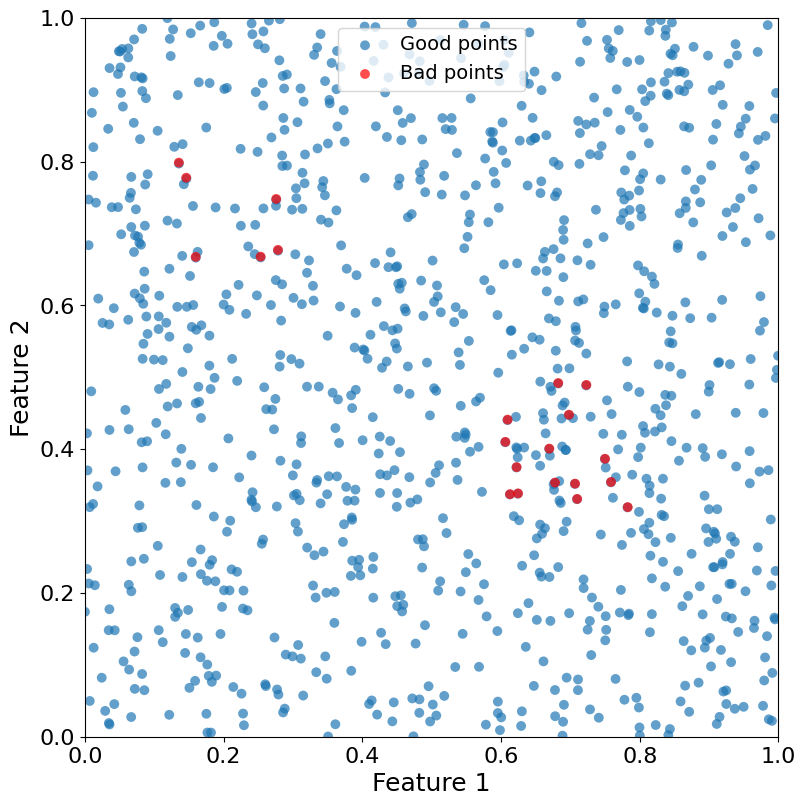

In [256]:
plt.figure(figsize=(8, 8))

plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.7, edgecolors='none', s=50, color='tab:blue', label='Good points')
plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='red', alpha=0.7, edgecolors='none', s=50, label='Bad points')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout(pad=0.5)
# plt.savefig('images/bad_X.pdf', dpi=300)
plt.show()

In [1133]:
# bad_data = data.loc[bad_y.index]

In [565]:
# low = [0.0] * 10
# up = [1.0] * 10
# num1_copy = [0.3, 0.4, 0.4, 0.5, 0.1]
# num2_copy = [0.1, 0.1, 0.8, 0.8, 0.9]

# tools.cxTwoPoint(num1_copy, num2_copy)
# tools.cxUniform(num1_copy, num2_copy, indpb= 0.4)
# tools.cxUniform([0, 0, 1], [1, 0, 0], indpb= 0.4)

In [172]:
# import random
# from deap import tools

# def cxOneHotOX(ind1, ind2, feature_sizes):
#     """
#     Order-Based Crossover (OX) для OneHot-кодированных признаков.
    
#     Args:
#         ind1: первая особь (list)
#         ind2: вторая особь (list)
#         feature_sizes: список размеров каждого OneHot-блока
        
#     Returns:
#         Кортеж из двух особей с сохранением валидности OneHot-векторов
#     """
#     # Проверяем, что особи одинаковой длины
#     assert len(ind1) == len(ind2), "Особи должны быть одинаковой длины"
    
#     # Создаем копии для безопасности
#     child1 = ind1[:]
#     child2 = ind2[:]
    
#     # Определяем границы блоков
#     boundaries = []
#     start = 0
#     for size in feature_sizes:
#         end = start + size
#         boundaries.append((start, end))
#         start = end
    
#     # Для каждого признака (блока) применяем OX
#     for start, end in boundaries:
#         # Выбираем случайные точки разрыва в пределах блока
#         if end - start < 2:
#             continue  # Пропускаем блоки размером 1
            
#         a, b = random.sample(range(start, end), 2)
#         point1, point2 = min(a, b), max(a, b)
        
#         # Копируем сегменты между точками разрыва
#         segment1 = child1[point1:point2]
#         segment2 = child2[point1:point2]
        
#         # Создаем маски для определения позиций единиц
#         ones_pos1 = [i for i in range(start, end) if child1[i] == 1]
#         ones_pos2 = [i for i in range(start, end) if child2[i] == 1]
        
#         # Заменяем сегменты
#         child1[point1:point2] = segment2
#         child2[point1:point2] = segment1
        
#         # Восстанавливаем валидность OneHot-векторов
#         repair_onehot_block(child1, start, end, ones_pos1)
#         repair_onehot_block(child2, start, end, ones_pos2)
    
#     return child1, child2

# def repair_onehot_block(individual, start, end, original_ones_pos):
#     """
#     Восстанавливает валидность OneHot-блока после скрещивания.
#     """
#     block = individual[start:end]
    
#     # Проверяем сумму элементов в блоке
#     block_sum = sum(block)
    
#     if block_sum == 1:
#         return  # Блок уже валиден
    
#     if block_sum == 0:
#         # Если все элементы нулевые, восстанавливаем исходную позицию единицы
#         if original_ones_pos and start <= original_ones_pos[0] < end:
#             individual[original_ones_pos[0]] = 1
#         else:
#             # Или выбираем случайную позицию
#             pos = random.randint(start, end-1)
#             individual[pos] = 1
    
#     elif block_sum > 1:
#         # Если больше одной единицы, оставляем только одну
#         ones_positions = [i for i in range(start, end) if individual[i] == 1]
        
#         # Оставляем только первую единицу, остальные обнуляем
#         for i, pos in enumerate(ones_positions):
#             if i == 0:
#                 continue  # Первую единицу оставляем
#             individual[pos] = 0

# # Пример использования в DEAP
# toolbox.register("mate", cxOneHotOX, feature_sizes=[3, 4, 2])  # Пример: 3 признака с 3, 4 и 2 категориями

In [ ]:
# def cxOneHotByFeature(ind1, ind2, feature_sizes):
#     child1 = ind1[:]
#     child2 = ind2[:]
    
#     start = 0
#     for size in feature_sizes:
#         end = start + size
#         if random.random() < 0.5:  # 50% chance to swap the feature
#             child1[start:end], child2[start:end] = child2[start:end], child1[start:end]
#         start = end
    
#     return child1, child2

In [20]:
def custom_crossover_num(ind1, ind2, num_eta=10):
    num1_copy = copy.deepcopy(ind1)
    num2_copy = copy.deepcopy(ind1)

    low = [0.0] * len(num1_copy)
    up = [1.0] * len(num1_copy)
    tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

    ind1 = num1_copy
    ind2 = num2_copy

    return ind1, ind2


def custom_crossover_num_ord(ind1, ind2, cat_indpb=0.3, num_eta=10):
    cat1 = ind1[:length_cat_ordinal]
    cat2 = ind2[:length_cat_ordinal]
    num1 = ind1[length_cat_ordinal:]
    num2 = ind2[length_cat_ordinal:]

    cat1_copy = copy.deepcopy(list(cat1))
    cat2_copy = copy.deepcopy(list(cat2))
    num1_copy = copy.deepcopy(list(num1))
    num2_copy = copy.deepcopy(list(num2))

    tools.cxUniform(cat1_copy, cat2_copy, indpb=cat_indpb)

    low = [0.0] * len(num1_copy)
    up = [1.0] * len(num1_copy)
    tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

    ind1[:] = cat1_copy + num1_copy
    ind2[:] = cat2_copy + num2_copy

    return ind1, ind2


# def custom_crossover_num_ord_nominal(ind1, ind2, cat_indpb=0.3, num_eta=10):
#     onehot1 = ind1[:sum(length_cat_onehot)]
#     onehot2 = ind2[:sum(length_cat_onehot)]
#     cat1 = ind1[sum(length_cat_onehot) : sum(length_cat_onehot) + length_cat_ordinal]
#     cat2 = ind2[sum(length_cat_onehot) : sum(length_cat_onehot) + length_cat_ordinal]
#     num1 = ind1[-length_num:]
#     num2 = ind2[-length_num:]

#     cat1_copy = copy.deepcopy(list(cat1))
#     cat2_copy = copy.deepcopy(list(cat2))
#     num1_copy = copy.deepcopy(list(num1))
#     num2_copy = copy.deepcopy(list(num2))

#     tools.cxUniform(cat1_copy, cat2_copy, indpb=cat_indpb)

#     low = [0.0] * len(num1_copy)
#     up = [1.0] * len(num1_copy)
#     tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

#     ind1[:] = cat1_copy + num1_copy
#     ind2[:] = cat2_copy + num2_copy

#     return ind1, ind2

In [21]:
def custom_mutate_num(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
    for i in range(len(individual)):
        mutation_prob = base_mutation_rate # * weights[i]
        
        if random.random() < mutation_prob:
            coef = linear_coefs[i]
            direction = 1 if coef * target_direction >= 0 else -1
            
            # noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
            noise = direction * abs(np.random.normal(0, 0.1 * mutation_strength))
            individual[i] = max(0, min(1, individual[i] + noise))
                
    return individual,


def custom_mutate_num_ord(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
    for i in range(len(individual)):
        mutation_prob = base_mutation_rate #* weights[i]
        
        if random.random() < mutation_prob:
            if i < length_dict['length_cat_ordinal']: 
                individual[i] = random.sample(list(bad_X.iloc[i].unique()), 1)[0]
            else: 
                # idx = i - len(cat_cols_name)
                coef = linear_coefs[i]
                
                direction = 1 if coef * target_direction >= 0 else -1
                
                # noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
                noise = direction * abs(np.random.normal(0, 0.1 * mutation_strength))
                individual[i] = max(0, min(1, individual[i] + noise))
                
    return individual,


# def custom_mutate(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
#     for i in range(len(individual)):
#         mutation_prob = base_mutation_rate * weights[i]
        
#         if random.random() < mutation_prob:
#             if i < len(cat_cols_name): 
#                 individual[i] = random.sample(list(X_exp[cat_cols_name[i]].unique()), 1)[0]
#             else: 
#                 # idx = i - len(cat_cols_name)
#                 coef = linear_coefs[i]
                
#                 direction = 1 if coef * target_direction >= 0 else -1
                
#                 noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
#                 individual[i] = max(0, min(1, individual[i] + noise))
                
#     return individual,

In [22]:
lr = LinearRegression(fit_intercept=False)
lr.fit(X_train, y_train)
linear_coefs = lr.coef_[0]

In [23]:
def augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps: int = 10):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()

    if (length_dict['length_cat_ordinal'] == 0) and (length_dict['length_cat_onehot'] == []):
        for i in range(length_dict['length_num']):
            # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
            toolbox.register(f"num_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        def make_individual():
            return creator.Individual(np.hstack([toolbox.__getattribute__(f"num_{i}")() for i in range(length_dict['length_num'])]))
            
        toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        toolbox.register("mate", custom_crossover_num)
            
            
    elif (length_dict['length_cat_ordinal'] != 0) and (length_dict['length_cat_onehot'] == []):
        for i in range(len(cat_columns)):
            toolbox.register(f"cat_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        for i in range(length_cat_ordinal, length_cat_ordinal + length_dict['length_num']):
            # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
            toolbox.register(f"num_{i - length_cat_ordinal}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        def make_individual():
            return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(length_cat_ordinal)] + \
                [toolbox.__getattribute__(f"num_{i}")() for i in range(length_dict['length_num'])])
            
        toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        toolbox.register("mate", custom_crossover_num_ord)
        
        
    else:
        return 0
        # for i, col in enumerate(cat_cols_name):
        #     toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
        
        # for i, col in enumerate(cat_cols_name):
        #     toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
            
        # for i in range(length_num):
        #     # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
        #     toolbox.register(f"num_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        # def make_individual():
        #     return 0
            
        # toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        # toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        # toolbox.register("mate", custom_crossover_num_ord_nominal)
        
        


    # def make_individual():
    #     if (length_cat_ordinal == 0) and (length_cat_onehot == []):
    #         return np.hstack([toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
            
    #     elif (length_cat_ordinal != 0) and (length_cat_onehot == []):
    #         return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(length_cat_ordinal)] + \
    #             [toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
            
    #     else:
    #         return 0

    toolbox.register("select", tools.selTournament, tournsize=3)
    
    steps = tqdm(range(len(bad_X)))
    best_individuals = []
    bad_y_sc_arr = []
    prediction_exp = baseline_model.predict(bad_X)
    
    

    for _ in range(num_steps):
        bad_y_scenario = np.maximum(np.minimum(0.0, y_test.min().values[0]),
                                    np.minimum(bad_y + np.random.normal(0, 0.1, (len(bad_y), 1)), np.maximum(1.0, y_test.max().values[0])))
        # bad_y_scenario = bad_y
        
        for i in steps:
            def eval_func(individual, y_target, linear_coefs, weights, target_direction, bonus_factor = 0.9):
                prediction = baseline_model.predict([individual])
                error = 0.5 * (prediction[0] - y_target.values[i])**2 - np.mean( (individual - bad_X.values[i])**2 )
                # bonus = 0
                # for k, val in enumerate(individual):
                #     # if k > len(cat_cols_name):
                #         coef = linear_coefs[k]
                #         base_val = X_exp.loc[idx_sc].iloc[i, k+1]
                        
                
                #         if coef * target_direction >= 0:  # Увеличение признака повышает таргет
                #             if val > base_val:
                #                 bonus += weights[k] * (val - base_val) * bonus_factor
                #         elif coef * target_direction < 0:  # Уменьшение признака повышает таргет
                #             if val < base_val:
                #                 bonus += weights[k] * (base_val - val) * bonus_factor
                                
                total_fitness = error #+ bonus
                return (total_fitness,)
            
            def main(target_direction, y_target):
                toolbox.register("evaluate", eval_func, y_target=y_target, 
                                linear_coefs=linear_coefs, weights=1, target_direction=target_direction)
                # toolbox.unregister("mutate")
                if length_dict['length_cat_ordinal'] == 0:
                    toolbox.register("mutate", custom_mutate_num, weights=1, linear_coefs=linear_coefs, 
                                target_direction=target_direction)
                else:
                    toolbox.register("mutate", custom_mutate_num_ord, weights=1, linear_coefs=linear_coefs, 
                                target_direction=target_direction)

                pop = toolbox.population(n=30)
                hof = tools.HallOfFame(1, similar=np.array_equal)
                stats = tools.Statistics(lambda ind: ind.fitness.values)
                stats.register("avg", lambda x: sum(i[0] for i in x)/len(x))
                stats.register("max", lambda x: max(i[0] for i in x))

                algorithms.eaSimple(pop, toolbox, 0.1, 0.1, 10, stats=stats, halloffame=hof, verbose=False)
                
                return hof[0]
        
            if bad_y_scenario.values[i] >= prediction_exp[i]:
                target_direction = 1
            else:
                target_direction = -1
            
            
            best_individual = main(target_direction, bad_y_scenario)
            best_individuals.append(best_individual)
            
        bad_y_sc_arr.append(bad_y_scenario.values.flatten())
        
    bad_y_sc_arr = np.hstack(bad_y_sc_arr)
    best_individuals = np.array(best_individuals)
    
    return best_individuals, bad_y_sc_arr

In [446]:
best_individuals, bad_y_sc_arr = augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps=10)

100%|██████████| 226/226 [00:03<00:00, 73.53it/s]


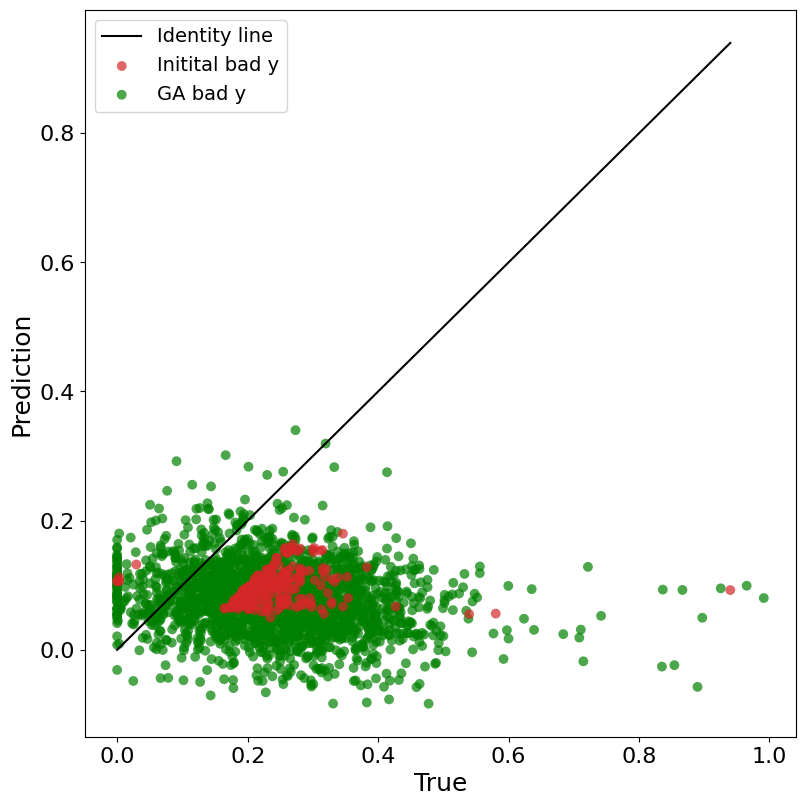

In [447]:
plt.figure(figsize=(8, 8))

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
plt.scatter(bad_y, baseline_model.predict(bad_X), alpha=0.7, label='Initital bad y', color='tab:red', zorder=3, edgecolors='none', s=50)
plt.scatter(bad_y_sc_arr, baseline_model.predict(best_individuals), alpha=0.7, label='GA bad y', color='green', edgecolors='none', s=50)

plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()

plt.tight_layout(pad=0.5)
# plt.savefig('images/prediction_best_ind_moscow.pdf', dpi=300)
plt.show()

In [174]:
# plt.figure(figsize=(8, 8))

# plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.7, edgecolors='none', s=50, color='tab:blue', label='Good points')
# plt.scatter(best_individuals[:, 0], best_individuals[:, 1], color='green', alpha=0.7, edgecolors='none', s=50, label='GA points')
# plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='red', alpha=0.7, edgecolors='none', s=50, label='Bad points')

# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')

# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend()
# plt.tight_layout(pad=0.5)
# # plt.savefig('images/GA_points.pdf', dpi=300)
# plt.show()

In [50]:
y_test.min()

0    0.002189
dtype: float64

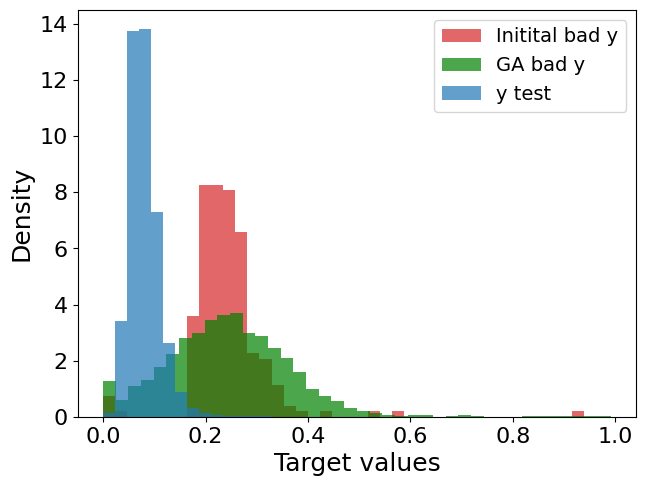

In [448]:
plt.hist(bad_y, bins=40, density=True, alpha=0.7, label='Initital bad y', color='tab:red')
plt.hist(bad_y_sc_arr, bins=40, density=True, alpha=0.7, label='GA bad y', color='green')
plt.hist(y_test, bins=40, density=True, alpha=0.7, label='y test', color='tab:blue')


plt.legend()
plt.xlabel('Target values')
plt.ylabel('Density')

plt.tight_layout(pad=0.5)
# plt.savefig('images/hist_ga_moscow.pdf', dpi=300)
plt.show()

In [26]:
# for i in range(len(X_train.columns)):
#     plt.hist(X_ex.iloc[:, i], bins=40, alpha=0.6, label='Initital X', color='black', density=True)
#     plt.hist(bad_X.iloc[:, i], bins=40, alpha=0.6, label='Initital bad X', color='tab:red', density=True)
#     plt.hist(np.array(best_individuals)[:, i], bins=40, alpha=0.6, label='Scenario bad X', color='tab:blue', density=True)

#     plt.legend()
#     plt.show()

In [408]:
# plt.subplots(figsize=(10, 5))

# vis_arr1 = []
# vis_arr2 = []

# for col in X_exp.columns.values:
#     vis_arr1.append((data.loc[idx_sc, col]/data.loc[idx_sc, col].max()).mean())
#     vis_arr2.append((scenario_df_GA[col]/scenario_df_GA[col].max()).mean())
#     # 
# plt.bar(X_exp.columns, vis_arr1, alpha=0.6, color='tab:blue', label='Initial data')
# plt.bar(X_exp.columns, vis_arr2, alpha=0.6, color='tab:red', label='Synth data')

# plt.xticks(rotation=90, fontsize=10)
# plt.ylabel('Mean value')
# plt.legend()
# plt.show()

In [449]:
bad_X_ga, bad_y_ga = select_bad_examples(pd.DataFrame(best_individuals), pd.DataFrame(bad_y_sc_arr), baseline_model.predict(best_individuals))

In [450]:
idx_rnd = np.arange(len(bad_X) + len(bad_X_ga))
np.random.shuffle(idx_rnd)

augmented_X = np.concatenate([bad_X.values, bad_X_ga.values])[idx_rnd]
augmented_y = np.concatenate([bad_y.values.flatten(), bad_y_ga.values.flatten()])[idx_rnd]

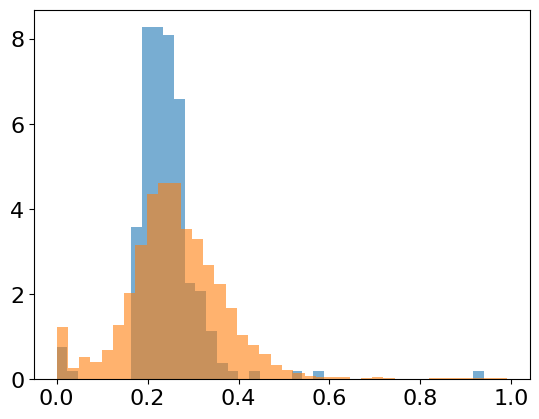

In [451]:
# plt.hist(y_test, density=True, alpha=0.6, bins=40)
plt.hist(bad_y, density=True, alpha=0.6, bins=40)
plt.hist(augmented_y, bins=40, density=True, alpha=0.6)
plt.show()

In [452]:
augmented_data = np.concatenate([augmented_X, augmented_y.reshape(-1, 1)], axis=1)

In [453]:
augmented_data.shape

(2151, 17)

## Generator

In [454]:
# scaler = MinMaxScaler()
# bad_data = scaler.fit_transform(bad_data)
data_tensor = np.array(augmented_data).astype('float32')
data_tensor = torch.tensor(data_tensor)

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Residual block
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm1d(channels)
        
        self.act = nn.ReLU()
        
        self.drop1 = nn.Dropout(0.1)
        self.drop2 = nn.Dropout(0.1)

    def forward(self, x):
        skip = x
        out = self.conv1(x)
        out = self.act(out)
        out = out + skip
        out = self.act(out)
        out = self.bn1(out)
        out = self.drop1(out)
        
        # skip2 = out
        # out = self.conv2(out)
        # out = self.act(out)
        # out = out + skip2
        # out = self.act(out)
        # out = self.bn2(out)
        # out = self.drop2(out)
        
        return out

# VAE model definition
class VAE(nn.Module):
    def __init__(self, input_channels=1, seq_length=128, latent_dim=16, hidden_channels=32):
        super(VAE, self).__init__()
        self.seq_length = seq_length
        self.latent_dim = latent_dim
        self.hidden_channels = hidden_channels

        
        self.enc_conv1 = nn.Conv1d(input_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn1 = nn.BatchNorm1d(hidden_channels)
        self.enc_res1 = ResidualBlock(hidden_channels)
   
        self.enc_conv2 = nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn2 = nn.BatchNorm1d(hidden_channels)
        self.enc_res2 = ResidualBlock(hidden_channels)

        self.h_dim_enc = seq_length * hidden_channels
        
        self.fc_mu = nn.Sequential(nn.Linear(1024, latent_dim))
        self.fc_logvar = nn.Sequential(nn.Linear(1024, latent_dim))
        self.fc_decode = nn.Sequential(nn.Linear(latent_dim, self.h_dim_enc))


        self.dec_conv1 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_bn1 = nn.BatchNorm1d(hidden_channels)
        self.dec_res1 = ResidualBlock(hidden_channels)
    
        self.dec_conv2 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_res2 = ResidualBlock(hidden_channels)
        self.dec_conv3 = nn.ConvTranspose1d(hidden_channels, input_channels, kernel_size=1)
        
        self.act = nn.ReLU()
        
        self.condition_encoder_beta = nn.Sequential(
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, latent_dim),
            self.act
        )
        
        self.condition_encoder_gamma = nn.Sequential(
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, latent_dim),
            self.act
        )
        
        self.condition_decoder_beta = nn.Sequential(
            nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
            self.act,
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, self.seq_length),
            self.act
        )
        
        self.condition_decoder_gamma = nn.Sequential(
            nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
            self.act,
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, self.seq_length),
            self.act
        )
        
        
        self.cat_flag = False
        if self.cat_flag:
            self.embedding = nn.Embedding(len(scalers['ord_encoder'].categories_[0]), 1)

        self.proj = nn.Sequential(nn.Linear(seq_length, 2**6),
                                      nn.ReLU(),
                                      nn.Linear(2**6, 2**6))
      
        

    def encode(self, x, y):
        if self.cat_flag:
            x = torch.cat([x[:,:,1:], self.embedding(x[:,:,0].long())], dim=2)
            
        
        # skip = x
        x = self.proj(x)
        x = self.enc_conv1(x)
        
        x = self.act(x)
        # x = self.enc_bn1(x)
        x = self.enc_res1(x)
        
        x = self.enc_conv2(x)
        x = self.act(x)
        # x = self.enc_bn2(x)
        x = self.enc_res2(x)
        
        x = x.view(x.size(0), -1)

        
        mu = self.fc_mu(x) * self.condition_encoder_beta(y).squeeze(1) + self.condition_encoder_gamma(y).squeeze(1)
        logvar = self.fc_logvar(x) * self.condition_encoder_beta(y).squeeze(1) + self.condition_encoder_gamma(y).squeeze(1)
        
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        # conv_out_length = (self.seq_length) // 4
        x = self.fc_decode(z)
        
        x = x.view(z.size(0), self.hidden_channels, self.seq_length)
        
        
        x = self.dec_conv1(x)
        
        x = self.act(x)
        # x = self.dec_bn1(x)
        x = self.dec_res1(x)
        
        x = self.dec_conv2(x)
        x = self.dec_res2(x) * self.condition_decoder_beta(y) + self.condition_decoder_gamma(y)
        
        x = self.dec_conv3(x)
        
        
        return x

    def forward(self, x):
        x, y = x[:,:,:-1], x[:,:,-1].unsqueeze(1)
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z, y)
        
        return recon_x, mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta):
    recon_loss = F.mse_loss(recon_x, x[:,:,:-1], reduction='mean')
    # kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = torch.mean( -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp() , dim=1) )
    return recon_loss + beta * kl_loss

# Training procedure
def train_vae(model, train_loader, num_epochs=500, learning_rate=1e-3, device=None):
    # if device is None:
        # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
        
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=2e-4)
    beta_sch = torch.cat([torch.tensor(np.linspace(0.0, 0.0005, num_epochs//2)), torch.tensor(np.linspace(0.0005, 0.0005, num_epochs//2))]).float().to(device)
    
    epochs = tqdm(range(num_epochs))
    
    losses = []
    model.train()
    for epoch in epochs:
        epoch_loss = 0
        
        for _, data in enumerate(train_loader):
            data = data.to(device)
            
            recon_data, mu, logvar = model(data)
            loss = vae_loss(recon_data, data, mu, logvar, beta_sch[epoch])
            
            optimizer.zero_grad()
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()
        
            epoch_loss += loss.item()
            
        scheduler.step()
        
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        losses.append(avg_loss)
        # print(optimizer.param_groups[0]['lr'])
        if epoch % 100 == 0:
            epochs.set_description(f'Average Loss: {avg_loss:.4f}')
            
    return losses      

In [ ]:
batch_size = 2**7
seq_length = len(augmented_data[0]) - 1
input_channels = 1

train_loader = torch.utils.data.DataLoader(data_tensor.unsqueeze(1), batch_size=batch_size, shuffle=True)

# Initialize the VAE model
model_vae = VAE(input_channels=input_channels, seq_length=seq_length, latent_dim=256, hidden_channels=16)

# Train the VAE
losses_vae = train_vae(model_vae, train_loader, num_epochs=2000, learning_rate=1e-3)

Average Loss: 0.0746:  16%|█▌        | 321/2000 [04:31<24:08,  1.16it/s]

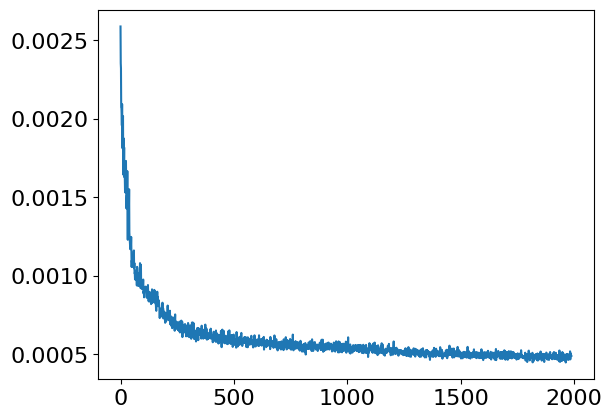

In [ ]:
plt.plot(losses_vae[10:])
plt.show()

In [ ]:
model_vae.eval()

synth_vae_arr = []

for i in range(5):
    synth_vae, mu, logvar = model_vae(data_tensor.unsqueeze(1).to(device))
    synth_vae = synth_vae.squeeze(1).detach().cpu().numpy()
    
    synth_vae_arr.append(synth_vae)
    
synth_vae = np.vstack(np.array(synth_vae_arr))

In [25]:
# for i in range(0, 5):
#     plt.hist(augmented_data[:, i], bins=40, alpha=0.7, density=True, label='Real')
#     plt.hist(synth_vae[:, i], bins=40, alpha=0.7, density=True, label='Synth')

#     plt.legend()
#     plt.show()

In [80]:
# synth_df = pd.DataFrame(np.concatenate([scaler_X_train.inverse_transform(synth_vae[:, :-1]), scaler_y_train.inverse_transform(synth_vae[:, -1].reshape(-1, 1))], axis=1), columns=data.columns)
# synth_df = pd.DataFrame(np.concatenate([scalers['scaler_X'].inverse_transform(synth_vae), scalers['scaler_y'].inverse_transform(data_tensor[:, -1].repeat(5).reshape(-1, 1))], axis=1))
synth_df = pd.DataFrame(np.concatenate([synth_vae, data_tensor[:, -1].repeat(5).reshape(-1, 1)], axis=1))

In [81]:
# plt.figure(figsize=(8, 8))

# plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.7, edgecolors='none', s=50, color='tab:blue', label='Good points')
# plt.scatter(best_individuals[:, 0], best_individuals[:, 1], color='green', alpha=0.7, edgecolors='none', s=50, label='GA points')
# plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='red', alpha=0.7, edgecolors='none', s=50, label='Bad points')
# plt.scatter(synth_df.iloc[:, 0], synth_df.iloc[:, 1], color='purple', alpha=0.5, edgecolors='none', s=50, label='VAE points')

# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')

# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend()
# plt.tight_layout(pad=0.5)
# # plt.savefig('images/VAE_points.pdf', dpi=300)
# plt.show()

In [82]:
# bad_data['pricemetr'].hist(bins=40,  alpha=0.7, density=True)
# synth_df['pricemetr'].hist(bins=40, alpha=0.7, density=True)

In [26]:
# plt.subplots(figsize=(8, 8))
# # synth_pred = xgb.predict(synth_df.drop('pricemetr', axis=1))
# X_tilde = synth_df.iloc[:, :-1]
# X_tilde.columns = X_train.columns

# synth_pred = baseline_model.predict(X_tilde)
# new_model_synth_pred = new_model.predict(X_tilde)

# # plt.scatter(bad_y.values, xgb.predict(bad_X), alpha=0.6, label='Real bad X', color='black')
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
# # plt.scatter(augmented_y, baseline_model.predict(augmented_X), alpha=0.6, label='Baseline model on augmented data', color='tab:green', edgecolors='none', s=50)
# # plt.scatter(augmented_y, new_model.predict(augmented_X), alpha=0.6, label='New model on augmented data', color='orange', edgecolors='none', s=50)
# plt.scatter(synth_df.iloc[:, -1], synth_pred, alpha=0.6, label='Baseline model on synth data', color='tab:red', edgecolors='none', s=50)
# plt.scatter(synth_df.iloc[:, -1], new_model_synth_pred, alpha=0.6, label='New model on synth data', color='orange', edgecolors='none', s=50)


# plt.xlabel('True')
# plt.ylabel('Prediction')
# plt.legend()
# plt.tight_layout(pad=0.5)
# # plt.savefig('images/vae_prediction_moscow.pdf', dpi=300)
# plt.show()

In [139]:
# plt.scatter(bad_y, xgb.predict(bad_X), alpha=0.6, label='Synth bad X', color='tab:red')
# plt.scatter(bad_y, new_reg_model.predict(bad_X), alpha=0.6, label='Synth bad X', color='orange')

# plt.scatter(augmented_y, baseline_model.predict(augmented_X), alpha=0.6, label='Augmented bad X', color='tab:red')
# plt.scatter(augmented_y, new_model.predict(augmented_X), alpha=0.6, label='Synth bad X', color='orange')

# plt.show()

In [431]:
mean_squared_error(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


(0.18654980186045972, 0.10364291421406717)

In [432]:
mean_squared_error(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))

(0.1321075223030864, 0.055830763065235114)

In [434]:
mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())

(0.1846150753877875, 0.10783112794160843)

In [27]:
def smape(A, F):
    return 1/len(A) * np.sum(2 * np.abs(F - A) / (np.abs(A) + np.abs(F) + np.finfo(float).eps))

In [28]:
def experiment(X: pd.DataFrame, y: pd.DataFrame, baseline_model, new_model, num_trials: int = 31):
    # evaluate_model(XGBRegressor(), X, y)
    
    eval_metrics = {'mse_aug_b': [], 'mse_bad_b': [], 'mse_synth_b': [],
                    'mse_aug_n': [], 'mse_bad_n': [], 'mse_synth_n': [],
                    'mape_aug_b': [], 'mape_bad_b': [], 'mape_synth_b': [],
                    'mape_aug_n': [], 'mape_bad_n': [], 'mape_synth_n': [],
                    'r2_aug_b': [], 'r2_bad_b': [], 'r2_synth_b': [],
                    'r2_aug_n': [], 'r2_bad_n': [], 'r2_synth_n': []}
    
    
    # num_columns = X.select_dtypes(include=[np.number]).columns.tolist()
    # cat_columns = np.setdiff1d(X.columns, num_columns)
    # length_cat_ordinal = len(cat_columns)
    # length_cat_onehot = []
    # length_num = len(num_columns)
    # length_dict = {'length_cat_ordinal': length_cat_ordinal, 'length_cat_onehot': length_cat_onehot, 'length_num': length_num}
    
    # num_columns = np.setdiff1d(X_ex.columns, ['Квартиры среднего качества (типовые)'])
    # cat_columns = ['Квартиры среднего качества (типовые)']

    # length_cat_ordinal = len(cat_columns)
    # length_cat_onehot = []
    # # length_num = len(X.iloc[0])
    # length_num = len(num_columns)

    # length_dict = {'length_cat_ordinal': length_cat_ordinal, 'length_cat_onehot': [], 'length_num': length_num}
    
    
    for _ in range(num_trials):
        X_train, X_test, y_train, y_test, scalers = split_and_transform(X, y)
        
        baseline_model = train_model(baseline_model, X_train, y_train)
        new_model = train_model(new_model, X_train, y_train)
        baseline_prediction = baseline_model.predict(X_test).flatten()
        
        bad_X, bad_y = select_bad_examples(X_test, y_test, baseline_prediction, 0.1)
        
        lr = LinearRegression(fit_intercept=False)
        lr.fit(X_train, y_train)
        linear_coefs = lr.coef_[0]
        
        best_individuals, bad_y_sc_arr = augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps=20)
        bad_X_ga, bad_y_ga = select_bad_examples(pd.DataFrame(best_individuals), pd.DataFrame(bad_y_sc_arr), baseline_model.predict(best_individuals))
        
        idx_rnd = np.arange(len(bad_X) + len(bad_X_ga))
        np.random.shuffle(idx_rnd)

        augmented_X = np.concatenate([bad_X.values, bad_X_ga.values])[idx_rnd]
        augmented_y = np.concatenate([bad_y.values.flatten(), bad_y_ga.values.flatten()])[idx_rnd]
        augmented_data = np.concatenate([augmented_X, augmented_y.reshape(-1, 1)], axis=1)
        
        
        data_tensor = np.array(augmented_data).astype('float32')
        data_tensor = torch.tensor(data_tensor)
        
        
        
        batch_size = 2**7
        seq_length = len(augmented_data[0]) - 1
        input_channels = 1
        train_loader = torch.utils.data.DataLoader(data_tensor.unsqueeze(1).to(device), batch_size=batch_size, shuffle=True)
        model_vae = VAE(input_channels=input_channels, seq_length=seq_length, latent_dim=256, hidden_channels=16).to(device)
        losses_vae = train_vae(model_vae, train_loader, num_epochs=1000, learning_rate=1e-3)
        
        model_vae.eval()
        synth_vae_arr = []
        for _ in range(5):
            synth_vae, mu, logvar = model_vae(data_tensor.unsqueeze(1).to(device))
            synth_vae = synth_vae.squeeze(1).detach().cpu().numpy()
            synth_vae_arr.append(synth_vae)
            
        synth_vae = np.vstack(np.array(synth_vae_arr))
        # synth_df = pd.DataFrame(np.concatenate([scalers['scaler_X'].inverse_transform(synth_vae),
                                                # scalers['scaler_y'].inverse_transform(data_tensor[:, -1].repeat(10).reshape(-1, 1))], axis=1))
                                                
        synth_df = pd.DataFrame(np.concatenate([synth_vae, data_tensor[:, -1].repeat(5).reshape(-1, 1)], axis=1))
        
        # synth_pred = baseline_model.predict(synth_df.drop(2, axis=1))
        # new_model_synth_pred = new_model.predict(synth_df.drop(2, axis=1))
        
        X_tilde = synth_df.iloc[:, :-1]
        X_tilde.columns = X_train.columns

        synth_pred = baseline_model.predict(X_tilde)
        new_model_synth_pred = new_model.predict(X_tilde)
        
        
        mse_aug_b = mean_squared_error(augmented_y, baseline_model.predict(augmented_X))
        mse_bad_b = mean_squared_error(bad_y.values.flatten(), baseline_model.predict(bad_X))
        mse_synth_b = mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten())
        
        mse_aug_n = mean_squared_error(augmented_y, new_model.predict(augmented_X))
        mse_bad_n = mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
        mse_synth_n = mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())
        
        
        mape_aug_b = smape(augmented_y, baseline_model.predict(augmented_X))
        mape_bad_b = smape(bad_y.values.flatten(), baseline_model.predict(bad_X))
        mape_synth_b = smape(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten())

        mape_aug_n = smape(augmented_y, new_model.predict(augmented_X))
        mape_bad_n = smape(bad_y.values.flatten(), new_model.predict(bad_X))
        mape_synth_n = smape(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())
        

        # mape_aug = mean_absolute_percentage_error(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))
        # mape_bad = mean_absolute_percentage_error(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
        # mape_synth = mean_absolute_percentage_error(data_tensor[:, -1].repeat(10).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(10).numpy(), new_model_synth_pred.flatten())
        
        # r2_aug = r2_score(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))
        # r2_bad = r2_score(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
        # r2_synth = r2_score(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())
        
        r2_aug_b = r2_score(augmented_y, baseline_model.predict(augmented_X))
        r2_bad_b = r2_score(bad_y.values.flatten(), baseline_model.predict(bad_X))
        r2_synth_b = r2_score(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten())
        
        r2_aug_n = r2_score(augmented_y, new_model.predict(augmented_X))
        r2_bad_n = r2_score(bad_y.values.flatten(), new_model.predict(bad_X))
        r2_synth_n = r2_score(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())
        
        
        
        
        eval_metrics['mse_aug_b'].append(mse_aug_b)
        eval_metrics['mse_bad_b'].append(mse_bad_b)
        eval_metrics['mse_synth_b'].append(mse_synth_b)
        
        eval_metrics['mse_aug_n'].append(mse_aug_n)
        eval_metrics['mse_bad_n'].append(mse_bad_n)
        eval_metrics['mse_synth_n'].append(mse_synth_n)
        

        eval_metrics['mape_aug_b'].append(mape_aug_b)
        eval_metrics['mape_bad_b'].append(mape_bad_b)
        eval_metrics['mape_synth_b'].append(mape_synth_b)

        eval_metrics['mape_aug_n'].append(mape_aug_n)
        eval_metrics['mape_bad_n'].append(mape_bad_n)
        eval_metrics['mape_synth_n'].append(mape_synth_n)

        
        eval_metrics['r2_aug_b'].append(r2_aug_b)
        eval_metrics['r2_bad_b'].append(r2_bad_b)
        eval_metrics['r2_synth_b'].append(r2_synth_b)
        
        eval_metrics['r2_aug_n'].append(r2_aug_n)
        eval_metrics['r2_bad_n'].append(r2_bad_n)
        eval_metrics['r2_synth_n'].append(r2_synth_n)
        
    eval_df_baseline = pd.DataFrame([
                            [f"{np.mean(eval_metrics['mse_aug_b']):.2f}+-{np.std(eval_metrics['mse_aug_b']):.2f}", 
                             f"{np.mean(eval_metrics['mse_bad_b']):.2f}+-{np.std(eval_metrics['mse_bad_b']):.2f}",
                             f"{np.mean(eval_metrics['mse_synth_b']):.2f}+-{np.std(eval_metrics['mse_synth_b']):.2f}"], 
                            
                            [f"{np.mean(eval_metrics['mape_aug_b']):.2f}+-{np.std(eval_metrics['mape_aug_b']):.2f}", 
                             f"{np.mean(eval_metrics['mape_bad_b']):.2f}+-{np.std(eval_metrics['mape_bad_b']):.2f}",
                             f"{np.mean(eval_metrics['mape_synth_b']):.2f}+-{np.std(eval_metrics['mape_synth_b']):.2f}"],
                            
                            [f"{np.mean(eval_metrics['r2_aug_b']):.2f}+-{np.std(eval_metrics['r2_aug_b']):.2f}", 
                             f"{np.mean(eval_metrics['r2_bad_b']):.2f}+-{np.std(eval_metrics['r2_bad_b']):.2f}",
                             f"{np.mean(eval_metrics['r2_synth_b']):.2f}+-{np.std(eval_metrics['r2_synth_b']):.2f}"]
                            ],
                           columns=['AUG, MEAN+STD', 'BAD, MEAN+STD', 'SYNTH, MEAN+STD'], index=['mse', 'smape', 'r2'])
    
    eval_df_new = pd.DataFrame([
                            [f"{np.mean(eval_metrics['mse_aug_n']):.2f}+-{np.std(eval_metrics['mse_aug_n']):.2f}", 
                             f"{np.mean(eval_metrics['mse_bad_n']):.2f}+-{np.std(eval_metrics['mse_bad_n']):.2f}",
                             f"{np.mean(eval_metrics['mse_synth_n']):.2f}+-{np.std(eval_metrics['mse_synth_n']):.2f}"], 
                            
                            [f"{np.mean(eval_metrics['mape_aug_n']):.2f}+-{np.std(eval_metrics['mape_aug_n']):.2f}", 
                             f"{np.mean(eval_metrics['mape_bad_n']):.2f}+-{np.std(eval_metrics['mape_bad_n']):.2f}",
                             f"{np.mean(eval_metrics['mape_synth_n']):.2f}+-{np.std(eval_metrics['mape_synth_n']):.2f}"],
                            
                            [f"{np.mean(eval_metrics['r2_aug_n']):.2f}+-{np.std(eval_metrics['r2_aug_n']):.2f}", 
                             f"{np.mean(eval_metrics['r2_bad_n']):.2f}+-{np.std(eval_metrics['r2_bad_n']):.2f}",
                             f"{np.mean(eval_metrics['r2_synth_n']):.2f}+-{np.std(eval_metrics['r2_synth_n']):.2f}"]
                            ],
                           columns=['AUG, MEAN+STD', 'BAD, MEAN+STD', 'SYNTH, MEAN+STD'], index=['mse', 'smape', 'r2'])
    
    return eval_df_baseline, eval_df_new

In [29]:
# baseline_model = train_model(LinearRegression(), X_train, y_train)
# new_model = train_model(XGBRegressor(), X_train, y_train)

In [30]:
import warnings
warnings.filterwarnings("ignore")

In [31]:
eval_df_baseline, eval_df_new = experiment(X_ex, y_ex, LinearRegression(), XGBRegressor(), num_trials=15)

Average Loss: 0.0003:  51%|█████     | 507/1000 [05:09<05:00,  1.64it/s]


KeyboardInterrupt: 

In [ ]:
eval_df_baseline

,"AUG, MEAN+STD","BAD, MEAN+STD","SYNTH, MEAN+STD"
mse,0.45+-0.05,0.45+-0.06,0.45+-0.05
smape,464.97+-107.57,22.27+-5.15,1.38+-0.14
r2,-32.81+-11.35,-56.63+-22.48,-32.81+-11.34


In [ ]:
eval_df_new

,"AUG, MEAN+STD","BAD, MEAN+STD","SYNTH, MEAN+STD"
mse,0.10+-0.05,0.04+-0.04,0.10+-0.05
smape,0.80+-0.15,0.33+-0.21,0.82+-0.15
r2,-6.97+-4.94,-4.31+-4.67,-6.87+-5.08
